# Índice de riesgo IRC4 — implementación operativa

Este cuaderno replica la propuesta de construcción del índice incluida en `contexto/Documento_final/borrador_documento_final.pdf` para el Indicador 4 del proyecto Kapak. La meta es transformar las probabilidades a nivel de pregunta en un índice continuo por proceso, listo para integrarse al tablero Kapak.


## 1. Configuración
- Cargamos las predicciones generadas en `kapak_indicador4_pipeline.ipynb` (archivo `evaluacion_preguntas_completo.csv`).
- Definimos rutas y constantes del esquema descrito en el documento (factores de contexto y pesos I+F+S).


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

BASE_DIR = Path('/home/mtituanai/tesis/entregable_2')
RESULTS_DIR = BASE_DIR / 'pipelines' / 'output_replica' / 'evaluation'
PRED_PATH = RESULTS_DIR / 'evaluacion_preguntas_completo.csv'
INDEX_PATH = RESULTS_DIR / 'indice_riesgo_procesos.csv'

WEIGHTS = {
    'intensidad': 0.45,
    'frecuencia': 0.35,
    'severidad': 0.20,
}

assert PRED_PATH.exists(), f'No se encuentra {PRED_PATH}'


In [2]:
df = pd.read_csv(PRED_PATH)
print(f'Preguntas disponibles: {len(df):,}')
print(f"Periodo: {df['fecha_publicacion'].min()} → {df['fecha_publicacion'].max()}")
print(f"Procesos únicos: {df['contract_id'].nunique():,}")
df.head(3)


Preguntas disponibles: 123,669
Periodo: 2024-01-05 → 2024-12-31
Procesos únicos: 15,087


,contract_id,codigo,fecha_publicacion,estado_del_proceso,presupuesto_referencial_total_sin_iva,monto_contrato,monto_adjudicacion,valor_preguntas,es_acusatoria,clasificacion,...,clasif_M2_opt,pred_M3_opt,clasif_M3_opt,pred_ens_opt,clasif_ens_opt,alerta,confianza,votos_opt,votos_def,mes
0,1835179,SIE-CELECEP-2023-15058,2024-01-05,Desierta,"$779,232.75",$0.00,$0.00,Se puede extender de 10 años a 15 años la temp...,False,No Acusatoria,...,No Acusatoria,0,No Acusatoria,0,No Acusatoria,SIN_ALERTA,0.0000,0,0,2024-01
1,1835179,SIE-CELECEP-2023-15058,2024-01-05,Desierta,"$779,232.75",$0.00,$0.00,"BUENAS NOCHES, SI EL OFERENTE ES ING CIVIL SE ...",False,No Acusatoria,...,No Acusatoria,0,No Acusatoria,0,No Acusatoria,SIN_ALERTA,0.0000,0,0,2024-01
2,1835179,SIE-CELECEP-2023-15058,2024-01-05,Desierta,"$779,232.75",$0.00,$0.00,Señores CELEC: En todo lo que respecta a la Vi...,False,No Acusatoria,...,Acusatoria,0,No Acusatoria,0,No Acusatoria,VERDE,0.0041,1,1,2024-01


## 2. Nivel 1 — Score ajustado por contexto
Fórmula del documento:

$$Score(c_i) = \minig(P_{ML}(c_i) 	imes Factor_{contexto}(c_i), 1.0ig)$$

con $Factor_{contexto} = 0.4 F_{etapa} + 0.3 F_{longitud} + 0.3 F_{técnico}$. A falta de metadatos adicionales en el dataset (todas las filas provienen de preguntas de proveedores), fijamos $F_{etapa}=1.3$ y dejamos parametrizadas las funciones para incorporar una columna futura (por ejemplo `tipo_actor`).


In [3]:
import re

TECH_KEYWORDS = [
    'pliego', 'resolucion', 'especificacion', 'garantia', 'anticipo',
    'oferta', 'habilitante', 'tecnico', 'planilla', 'contrato',
]

SEVERITY_PATTERNS = [
    (r'direccion|amañ|favore', 0.90, 'Direccionamiento'),
    (r'sobreprecio|sobre\s*costo', 0.60, 'Sobreprecio'),
    (r'colusi|cartel|acuerdo', 0.85, 'Colusión'),
    (r'garantia|póliza|fianza', 0.55, 'Garantías'),
    (r'pliegos|documento|requisito', 0.40, 'Documental'),
]

def factor_etapa(row):
    if 'tipo_actor' in row.index and isinstance(row['tipo_actor'], str):
        return 1.3 if row['tipo_actor'].lower().startswith('proveedor') else 0.8
    return 1.3

def factor_longitud(text):
    n = len(text)
    if n > 500:
        return 1.2
    if n >= 100:
        return 1.0
    return 0.8

def factor_tecnico(text):
    tokens = text.lower()
    hits = sum(1 for kw in TECH_KEYWORDS if kw in tokens)
    return min(1.0 + 0.1 * hits, 1.5)

def severity_from_text(text):
    tokens = text.lower()
    best = (0.0, 'Sin taxonomía')
    for pattern, weight, label in SEVERITY_PATTERNS:
        if re.search(pattern, tokens):
            if weight > best[0]:
                best = (weight, label)
    return best


In [4]:
df['factor_etapa'] = df.apply(factor_etapa, axis=1)
df['factor_longitud'] = df['valor_preguntas'].fillna('').apply(factor_longitud)
df['factor_tecnico'] = df['valor_preguntas'].fillna('').apply(factor_tecnico)

df['factor_contexto'] = (
    0.4 * df['factor_etapa'] +
    0.3 * df['factor_longitud'] +
    0.3 * df['factor_tecnico']
)

df['score_ctx'] = (df['P_M1'] * df['factor_contexto']).clip(0, 1)
df[['contract_id', 'valor_preguntas', 'P_M1', 'factor_contexto', 'score_ctx']].head(3)


,contract_id,valor_preguntas,P_M1,factor_contexto,score_ctx
0,1835179,Se puede extender de 10 años a 15 años la temp...,0.0000,1.09,0.000000
1,1835179,"BUENAS NOCHES, SI EL OFERENTE ES ING CIVIL SE ...",0.0000,1.06,0.000000
2,1835179,Señores CELEC: En todo lo que respecta a la Vi...,0.0041,1.24,0.005084


## 3. Taxonomía de severidad
Aplicamos la tabla sugerida en el documento (ejemplos: Direccionamiento = 0.9, Sobreprecio = 0.6). El puntaje del proceso será el máximo de las señales detectadas.


In [5]:
sev = df['valor_preguntas'].fillna('').apply(severity_from_text)
df['severity_weight'] = sev.map(lambda x: x[0])
df['severity_label'] = sev.map(lambda x: x[1])

df[['valor_preguntas', 'severity_label', 'severity_weight']].head(3)


,valor_preguntas,severity_label,severity_weight
0,Se puede extender de 10 años a 15 años la temp...,Sin taxonomía,0.00
1,"BUENAS NOCHES, SI EL OFERENTE ES ING CIVIL SE ...",Sin taxonomía,0.00
2,Señores CELEC: En todo lo que respecta a la Vi...,Garantías,0.55


## 4. Nivel 2 — Agregación por proceso (IFS)
Para cada proceso calculamos:

- **Intensidad $I_p$**: promedio de `score_ctx`.
- **Frecuencia $F_p$**: fracción de preguntas con `score_ctx ≥ 0.60`.
- **Severidad $S_p$**: máximo `severity_weight` observado.

El índice final es $IRC4_p = 100 	imes (0.45 I_p + 0.35 F_p + 0.20 S_p)$.


In [6]:
def agg_process(group):
    data = {}
    data['codigo'] = group['codigo'].iloc[0]
    data['fecha_publicacion'] = group['fecha_publicacion'].iloc[0]
    data['n_preguntas'] = len(group)
    data['n_con_senal'] = (group['score_ctx'] >= 0.6).sum()
    data['intensidad'] = group['score_ctx'].mean()
    data['frecuencia'] = (group['score_ctx'] >= 0.6).mean()
    data['severidad'] = group['severity_weight'].max()
    data['max_score'] = group['score_ctx'].max()
    data['alerta_max_proceso'] = group['alerta'].max() if 'alerta' in group else np.nan
    data['severidad_label'] = group.loc[group['severity_weight'].idxmax(), 'severity_label'] if data['severidad'] > 0 else 'Sin taxonomía'
    return pd.Series(data)

process_index = df.groupby('contract_id').apply(agg_process).reset_index()
process_index['severidad'] = process_index['severidad'].fillna(0)
process_index['irc4'] = 100 * (
    WEIGHTS['intensidad'] * process_index['intensidad'] +
    WEIGHTS['frecuencia'] * process_index['frecuencia'] +
    WEIGHTS['severidad'] * process_index['severidad']
)
process_index.sort_values('irc4', ascending=False).head(10)


/tmp/ipykernel_3790142/378174668.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  process_index = df.groupby('contract_id').apply(agg_process).reset_index()


,contract_id,codigo,fecha_publicacion,n_preguntas,n_con_senal,intensidad,frecuencia,severidad,max_score,alerta_max_proceso,severidad_label,irc4
3819,1859830,SIE-GADPRPANO-2024-00002,2024-05-17,1,1,1.0,1.0,0.9,1.0,AMARILLA,Direccionamiento,98.0
13518,1914621,SIE-COS2-2024-018,2024-12-02,2,2,1.0,1.0,0.9,1.0,AMARILLA,Direccionamiento,98.0
9384,1890793,SIE-CBCPJL-2024-4,2024-09-16,3,3,1.0,1.0,0.9,1.0,ROJA,Direccionamiento,98.0
2215,1850017,SIE-CZ3INEC-2024-001,2024-04-11,3,3,1.0,1.0,0.9,1.0,ROJA,Direccionamiento,98.0
4546,1864206,SIE-GADGIRON-2024-08,2024-06-05,1,1,1.0,1.0,0.9,1.0,AMARILLA,Direccionamiento,98.0
5041,1867296,SIE-GADMCHONE-2024-26,2024-06-18,2,2,1.0,1.0,0.9,1.0,AMARILLA,Direccionamiento,98.0
3999,1860978,SIE-HGLPS-2024-032,2024-05-22,1,1,1.0,1.0,0.9,1.0,AMARILLA,Direccionamiento,98.0
6815,1877019,SIE-GADPARROQUIALRUARALELTINGO-2024-0001,2024-07-25,1,1,1.0,1.0,0.9,1.0,ROJA,Direccionamiento,98.0
14127,1918381,SIE-GADPCOJ-2024-001,2024-12-12,2,2,1.0,1.0,0.9,1.0,ROJA,Direccionamiento,98.0
10953,1899777,SIE-CONAGOPARE-CANAR-2024-00001,2024-10-18,1,1,1.0,1.0,0.9,1.0,AMARILLA,Direccionamiento,98.0


## 5. Resumen y exportación
Guardamos la tabla consolidada para integrarla al pipeline Kapak y dejamos algunas métricas rápidas para control.


In [7]:
print('Procesos evaluados:', len(process_index))
print('IRC4 — percentiles:', process_index['irc4'].quantile([0.5, 0.8, 0.95]).round(2).to_dict())
print('Top 5 severidades:', process_index['severidad_label'].value_counts().head())

process_index.to_csv(INDEX_PATH, index=False)
print(f'Guardado: {INDEX_PATH}')


Procesos evaluados: 15087
IRC4 — percentiles: {0.5: 8.01, 0.8: 18.08, 0.95: 32.56}
Top 5 severidades: severidad_label
Sin taxonomía       7590
Colusión            2929
Direccionamiento    2198
Documental          2143
Garantías            221
Name: count, dtype: int64
Guardado: /home/mtituanai/tesis/entregable_2/pipelines/output_replica/evaluation/indice_riesgo_procesos.csv


## 6. Validación del IRC4 — concordancia con la BD

Analizamos cómo se relaciona el IRC4 (score continuo 0–100) con el indicador
binario de la BD (`proceso_acusatorio_bd = n_acus_bd ≥ 1`).

**No asumimos que la BD es el ground truth absoluto.** El objetivo es identificar
los cuatro cuadrantes de concordancia/discordancia y entender qué significan.

In [8]:
# ============================================================
# 6a. Preparar dataset de validación
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Ground truth de la BD agregado por proceso
bd_agg = df.groupby('contract_id').agg(
    n_acus_bd       = ('label', 'sum'),
    n_preguntas_bd  = ('label', 'count'),
).reset_index()
bd_agg['pct_acus_bd']           = bd_agg['n_acus_bd'] / bd_agg['n_preguntas_bd']
bd_agg['proceso_acusatorio_bd'] = (bd_agg['n_acus_bd'] > 0).astype(int)

val = process_index.merge(bd_agg, on='contract_id', how='inner')

n_total = len(val)
n_bd1   = val['proceso_acusatorio_bd'].sum()
n_bd0   = n_total - n_bd1

print(f"Procesos en validación : {n_total:,}")
print(f"BD = 1 (acusatorio)    : {n_bd1:,}  ({n_bd1/n_total:.1%})")
print(f"BD = 0 (limpio)        : {n_bd0:,}  ({n_bd0/n_total:.1%})")

for label, mask in [('BD=0', val['proceso_acusatorio_bd']==0),
                    ('BD=1', val['proceso_acusatorio_bd']==1)]:
    sub = val.loc[mask, 'irc4']
    print(f"\nIRC4 — {label}: media={sub.mean():.2f}  mediana={sub.median():.2f}"
          f"  p25={sub.quantile(.25):.2f}  p75={sub.quantile(.75):.2f}")

Procesos en validación : 15,087
BD = 1 (acusatorio)    : 3,205  (21.2%)
BD = 0 (limpio)        : 11,882  (78.8%)

IRC4 — BD=0: media=7.51  mediana=0.34  p25=0.01  p75=17.01

IRC4 — BD=1: media=21.12  mediana=18.20  p25=17.01  p75=24.17


## 6b. Correlaciones: punto-biserial, Pearson, Spearman

Las tres miden *concordancia de dirección* entre IRC4 y el binario BD.
Una correlación **moderada** (ρ ≈ 0.4–0.6) es el resultado más útil:
confirma señal compartida pero evidencia que el IRC4 captura dimensiones
que la heurística binaria no registra.

=== Correlaciones IRC4 ↔ proceso_acusatorio_bd ===
  Punto-biserial : r = +0.4067   p = 0.00e+00
  Pearson        : r = +0.4067   p = 0.00e+00
  Spearman       : ρ = +0.4538   p = 0.00e+00

=== Tests de distribución ===
  Mann-Whitney U (BD=1 > BD=0): U=31231610   p=0.00e+00
  KS test (distribuciones distintas): D=0.5234   p=0.00e+00


/tmp/ipykernel_3790142/189265720.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=val_plot, x='bd_label', y='irc4', ax=ax,


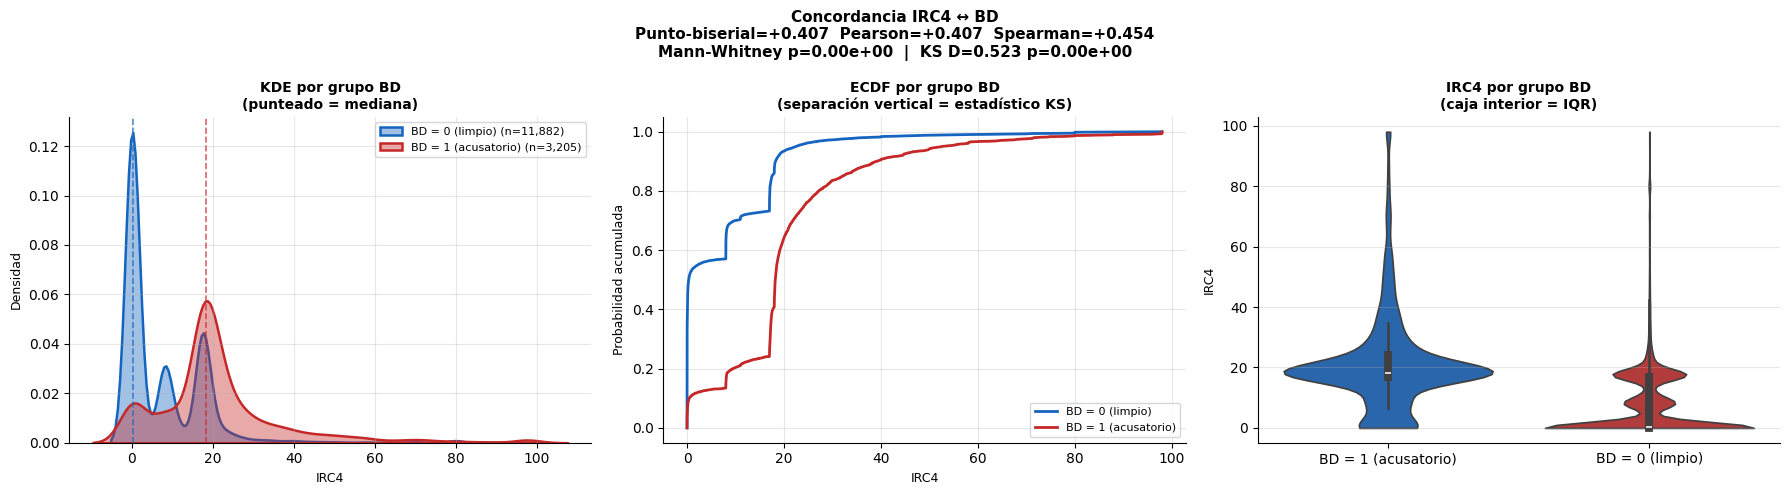

Guardado: validacion_correlaciones.png


In [9]:
# ============================================================
# 6b. Correlaciones + tests estadísticos + visualización
# ============================================================
r_pb, p_pb = stats.pointbiserialr(val['proceso_acusatorio_bd'], val['irc4'])
r_pe, p_pe = stats.pearsonr(val['irc4'], val['proceso_acusatorio_bd'].astype(float))
r_sp, p_sp = stats.spearmanr(val['irc4'], val['proceso_acusatorio_bd'])
mw_stat, mw_p = stats.mannwhitneyu(
    val.loc[val['proceso_acusatorio_bd']==1, 'irc4'],
    val.loc[val['proceso_acusatorio_bd']==0, 'irc4'],
    alternative='greater'
)
ks_stat, ks_p = stats.ks_2samp(
    val.loc[val['proceso_acusatorio_bd']==1, 'irc4'],
    val.loc[val['proceso_acusatorio_bd']==0, 'irc4'],
)

print("=== Correlaciones IRC4 ↔ proceso_acusatorio_bd ===")
print(f"  Punto-biserial : r = {r_pb:+.4f}   p = {p_pb:.2e}")
print(f"  Pearson        : r = {r_pe:+.4f}   p = {p_pe:.2e}")
print(f"  Spearman       : ρ = {r_sp:+.4f}   p = {p_sp:.2e}")
print(f"\n=== Tests de distribución ===")
print(f"  Mann-Whitney U (BD=1 > BD=0): U={mw_stat:.0f}   p={mw_p:.2e}")
print(f"  KS test (distribuciones distintas): D={ks_stat:.4f}   p={ks_p:.2e}")

# ── Visualización ────────────────────────────────────────────
colors     = {0: '#1565C0', 1: '#C62828'}
labels_map = {0: 'BD = 0 (limpio)', 1: 'BD = 1 (acusatorio)'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Concordancia IRC4 ↔ BD\n'
    f'Punto-biserial={r_pb:+.3f}  Pearson={r_pe:+.3f}  Spearman={r_sp:+.3f}\n'
    f'Mann-Whitney p={mw_p:.2e}  |  KS D={ks_stat:.3f} p={ks_p:.2e}',
    fontsize=11, fontweight='bold'
)

# Panel A: KDE overlay
ax = axes[0]
for bd_val, color in colors.items():
    sub = val.loc[val['proceso_acusatorio_bd'] == bd_val, 'irc4']
    sns.kdeplot(sub, ax=ax, color=color, fill=True, alpha=0.4,
                linewidth=1.8, label=f"{labels_map[bd_val]} (n={len(sub):,})")
    ax.axvline(sub.median(), color=color, lw=1.2, linestyle='--', alpha=0.7)
ax.set_xlabel('IRC4', fontsize=9)
ax.set_ylabel('Densidad', fontsize=9)
ax.set_title('KDE por grupo BD\n(punteado = mediana)', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
sns.despine(ax=ax)

# Panel B: ECDF
ax = axes[1]
for bd_val, color in colors.items():
    sub = val.loc[val['proceso_acusatorio_bd'] == bd_val, 'irc4'].sort_values()
    ecdf = np.arange(1, len(sub) + 1) / len(sub)
    ax.plot(sub.values, ecdf, color=color, lw=2, label=labels_map[bd_val])
ax.set_xlabel('IRC4', fontsize=9)
ax.set_ylabel('Probabilidad acumulada', fontsize=9)
ax.set_title('ECDF por grupo BD\n(separación vertical = estadístico KS)', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
sns.despine(ax=ax)

# Panel C: Violin
ax = axes[2]
val_plot = val.copy()
val_plot['bd_label'] = val_plot['proceso_acusatorio_bd'].map(labels_map)
sns.violinplot(data=val_plot, x='bd_label', y='irc4', ax=ax,
               palette=[colors[0], colors[1]], inner='box', cut=0)
ax.set_xlabel('', fontsize=9)
ax.set_ylabel('IRC4', fontsize=9)
ax.set_title('IRC4 por grupo BD\n(caja interior = IQR)', fontsize=10, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validacion_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: validacion_correlaciones.png')

## 6c. Análisis de cuadrantes — dónde discrepan BD e IRC4

El umbral sobre IRC4 divide el espacio en cuatro cuadrantes:

| | IRC4 ≥ umbral | IRC4 < umbral |
|---|---|---|
| **BD = 1** | Acuerdo acusatorio | **Discordancia A**: BD exagera? |
| **BD = 0** | **Discordancia B**: IRC4 detecta algo nuevo? | Acuerdo limpio |

Las discordancias son el núcleo del argumento de refinamiento del índice.

Umbral IRC4 = 17.01  (percentil 25 de BD=1)

=== Tamaño de cuadrantes ===
  Acuerdo limpio                        : 9,038  (59.9%)
  Discordancia B  (BD=0, IRC4 alto)     : 2,844  (18.9%)
  Acuerdo acusatorio                    : 2,404  (15.9%)
  Discordancia A  (BD=1, IRC4 bajo)     :   801  (5.3%)


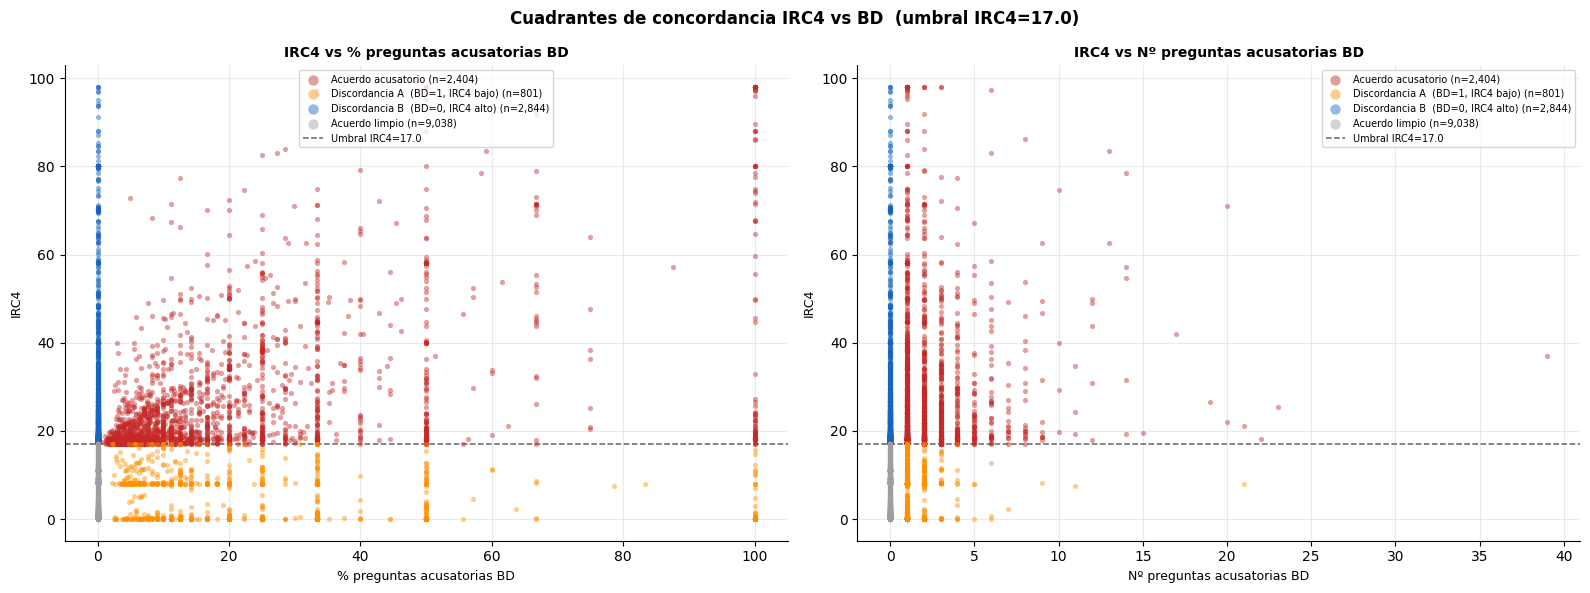

Guardado: validacion_cuadrantes_scatter.png


In [10]:
# ============================================================
# 6c. Cuadrantes de concordancia/discordancia
# ============================================================

# Umbral: percentil 25 de los procesos BD=1
# (los BD=1 más débiles quedan bajo el umbral → Discordancia A)
UMBRAL_IRC4 = val.loc[val['proceso_acusatorio_bd']==1, 'irc4'].quantile(0.25)
print(f"Umbral IRC4 = {UMBRAL_IRC4:.2f}  (percentil 25 de BD=1)")

val['irc4_alto'] = val['irc4'] >= UMBRAL_IRC4

def _quad(row):
    bd  = row['proceso_acusatorio_bd'] == 1
    irc = row['irc4_alto']
    if   bd and     irc: return 'Acuerdo acusatorio'
    elif bd and not irc: return 'Discordancia A  (BD=1, IRC4 bajo)'
    elif not bd and irc: return 'Discordancia B  (BD=0, IRC4 alto)'
    else:                return 'Acuerdo limpio'

val['cuadrante'] = val.apply(_quad, axis=1)

counts = val['cuadrante'].value_counts()
print("\n=== Tamaño de cuadrantes ===")
for q, n in counts.items():
    pct = n / len(val) * 100
    print(f"  {q:<38}: {n:5,}  ({pct:.1f}%)")

# ── Scatters ─────────────────────────────────────────────────
QUAD_COLORS = {
    'Acuerdo acusatorio':               '#C62828',
    'Discordancia A  (BD=1, IRC4 bajo)': '#FF8F00',
    'Discordancia B  (BD=0, IRC4 alto)': '#1565C0',
    'Acuerdo limpio':                    '#9E9E9E',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'Cuadrantes de concordancia IRC4 vs BD  (umbral IRC4={UMBRAL_IRC4:.1f})',
    fontsize=12, fontweight='bold'
)

for ax, xcol, xlabel in [
    (axes[0], 'pct_acus_bd', '% preguntas acusatorias BD'),
    (axes[1], 'n_acus_bd',   'Nº preguntas acusatorias BD'),
]:
    xvals = val[xcol] * 100 if xcol == 'pct_acus_bd' else val[xcol]
    for quad, color in QUAD_COLORS.items():
        mask = val['cuadrante'] == quad
        ax.scatter(xvals[mask], val.loc[mask, 'irc4'],
                   c=color, label=f"{quad} (n={mask.sum():,})",
                   alpha=0.45, s=14, linewidths=0, zorder=3)
    ax.axhline(UMBRAL_IRC4, color='black', lw=1.1, linestyle='--',
               alpha=0.6, label=f'Umbral IRC4={UMBRAL_IRC4:.1f}')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('IRC4', fontsize=9)
    ax.set_title(f'IRC4 vs {xlabel}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, markerscale=2)
    ax.grid(alpha=0.25)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validacion_cuadrantes_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: validacion_cuadrantes_scatter.png')

## 6d. Inspección de discordancias

Examinamos los casos donde BD e IRC4 no coinciden para identificar si la
discrepancia tiene una explicación estructural (ej. la BD reacciona a una sola
pregunta muy débil).


  DISCORDANCIA A — BD=1 pero IRC4 bajo  (n=801)
  Hipótesis: La BD reacciona a ≥1 pregunta; el IRC4 pondera intensidad+frecuencia+severidad
  n_acus_bd   → mediana=1  media=1.3
  pct_acus_bd → mediana=16.67%  media=25.54%
  IRC4        → mediana=3.31  media=5.18
  Severidad 'Sin taxonomía': 57.6%

  Primeros 8 casos:
 contract_id                 codigo  n_preguntas_bd  n_acus_bd  pct_acus_bd  intensidad  frecuencia  severidad severidad_label  irc4
     1848627       SIE-CEC-2024-001               2          1     0.500000         0.0         0.0        0.0   Sin taxonomía   0.0
     1862140    SIE-EMGIRS-2024-015               5          1     0.200000         0.0         0.0        0.0   Sin taxonomía   0.0
     1867653 SIE-CELECEP-2024-10065               5          2     0.400000         0.0         0.0        0.0   Sin taxonomía   0.0
     1923978    SIE-GADCCC-2024-018               4          1     0.250000         0.0         0.0        0.0   Sin taxonomía   0.0
     1853448   

/tmp/ipykernel_3790142/929389905.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=val, x='cuadrante', y='irc4', order=order,
/tmp/ipykernel_3790142/929389905.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Acuerdo\nacusatorio', 'Discordancia A\n(BD=1, IRC4↓)',


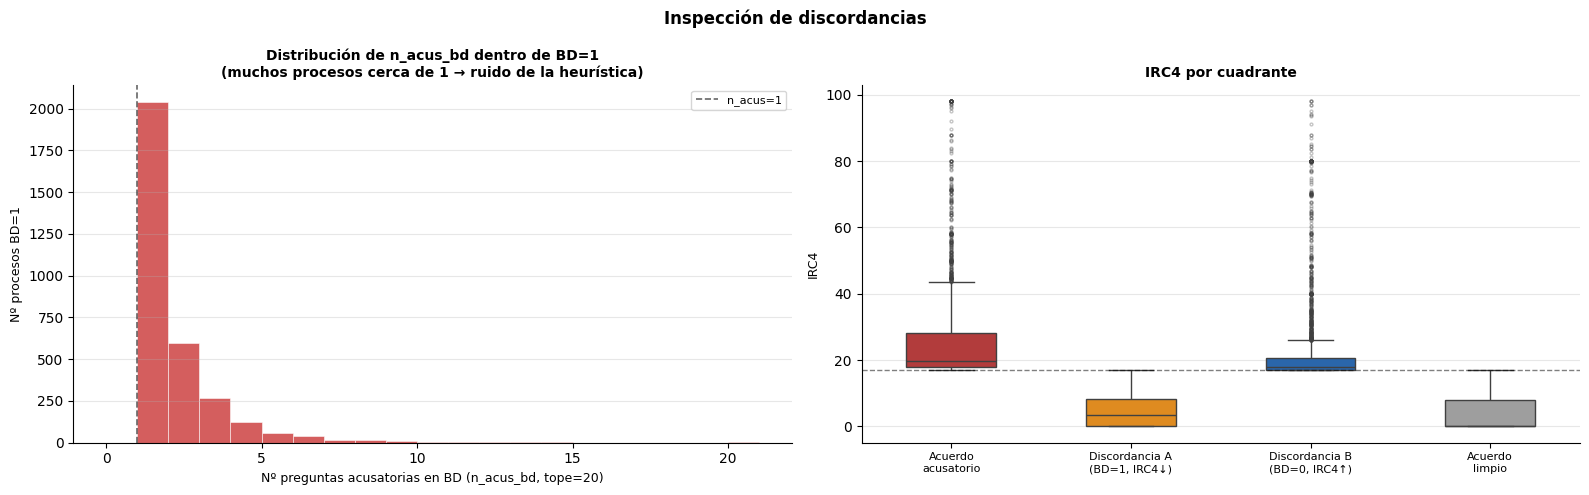

Guardado: validacion_discordancias.png


In [11]:
# ============================================================
# 6d. Inspección de discordancias
# ============================================================

COLS = ['contract_id', 'codigo', 'n_preguntas_bd', 'n_acus_bd', 'pct_acus_bd',
        'intensidad', 'frecuencia', 'severidad', 'severidad_label', 'irc4']

disc_A = val[val['cuadrante'] == 'Discordancia A  (BD=1, IRC4 bajo)'].sort_values('irc4')
disc_B = val[val['cuadrante'] == 'Discordancia B  (BD=0, IRC4 alto)'].sort_values('irc4', ascending=False)

# ── Resumen estadístico de cada cuadrante ───────────────────
for label, sub, hyp in [
    ('DISCORDANCIA A — BD=1 pero IRC4 bajo', disc_A,
     'La BD reacciona a ≥1 pregunta; el IRC4 pondera intensidad+frecuencia+severidad'),
    ('DISCORDANCIA B — BD=0 pero IRC4 alto', disc_B,
     'El IRC4 capta intensidad/severidad que la heurística binaria no registra'),
]:
    print(f"\n{'='*60}")
    print(f"  {label}  (n={len(sub):,})")
    print(f"  Hipótesis: {hyp}")
    print(f"{'='*60}")
    print(f"  n_acus_bd   → mediana={sub['n_acus_bd'].median():.0f}  media={sub['n_acus_bd'].mean():.1f}")
    print(f"  pct_acus_bd → mediana={sub['pct_acus_bd'].median():.2%}  media={sub['pct_acus_bd'].mean():.2%}")
    print(f"  IRC4        → mediana={sub['irc4'].median():.2f}  media={sub['irc4'].mean():.2f}")
    print(f"  Severidad 'Sin taxonomía': {(sub['severidad_label']=='Sin taxonomía').mean():.1%}")
    print(f"\n  Primeros 8 casos:")
    print(sub[COLS].head(8).to_string(index=False))

# ── Ruido de la BD: distribución de n_acus_bd dentro de BD=1 ─
print("\n\n=== Distribución de n_acus_bd dentro de BD=1 ===")
print("Muestra cuántos procesos BD=1 tienen solo 1–2 preguntas acusatorias (ruido potencial)")
bd1 = val[val['proceso_acusatorio_bd']==1]
dist = bd1['n_acus_bd'].value_counts().sort_index().head(20)
for n_val, cnt in dist.items():
    pct = cnt / len(bd1) * 100
    bar = '█' * max(1, int(pct / 1.5))
    print(f"  n_acus_bd = {int(n_val):3d}: {cnt:5,} procesos  ({pct:5.1f}%)  {bar}")

# ── Figura: distribución de n_acus_bd en BD=1 + boxplot cuadrantes ───────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Inspección de discordancias', fontsize=12, fontweight='bold')

ax = axes[0]
bd1_counts = bd1['n_acus_bd'].clip(upper=20)
ax.hist(bd1_counts, bins=range(0, 22), color='#C62828', alpha=0.75, edgecolor='white', lw=0.5)
ax.set_xlabel('Nº preguntas acusatorias en BD (n_acus_bd, tope=20)', fontsize=9)
ax.set_ylabel('Nº procesos BD=1', fontsize=9)
ax.set_title('Distribución de n_acus_bd dentro de BD=1\n(muchos procesos cerca de 1 → ruido de la heurística)', fontsize=10, fontweight='bold')
ax.axvline(1, color='black', lw=1.2, linestyle='--', alpha=0.6, label='n_acus=1')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')
sns.despine(ax=ax)

ax = axes[1]
order = ['Acuerdo acusatorio', 'Discordancia A  (BD=1, IRC4 bajo)',
         'Discordancia B  (BD=0, IRC4 alto)', 'Acuerdo limpio']
palette = [QUAD_COLORS[q] for q in order]
sns.boxplot(data=val, x='cuadrante', y='irc4', order=order,
            palette=palette, ax=ax, width=0.5, fliersize=2, flierprops=dict(alpha=0.3))
ax.set_xticklabels(['Acuerdo\nacusatorio', 'Discordancia A\n(BD=1, IRC4↓)',
                    'Discordancia B\n(BD=0, IRC4↑)', 'Acuerdo\nlimpio'], fontsize=8)
ax.set_xlabel('', fontsize=9)
ax.set_ylabel('IRC4', fontsize=9)
ax.set_title('IRC4 por cuadrante', fontsize=10, fontweight='bold')
ax.axhline(UMBRAL_IRC4, color='black', lw=1, linestyle='--', alpha=0.5)
ax.grid(alpha=0.3, axis='y')
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validacion_discordancias.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: validacion_discordancias.png')